In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_moons

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

C:\Users\munna\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
X,y = make_moons(100, noise=0.25, random_state=2)

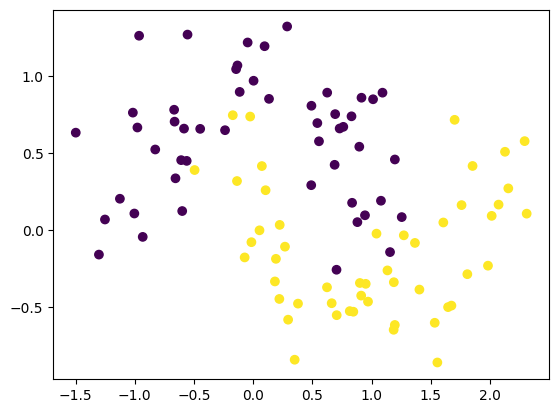

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [5]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

C:\Users\munna\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
adam = Adam(learning_rate=0.01)

In [7]:
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

In [8]:
history1 = model1.fit(X,y, epochs=2000, validation_split=0.2, verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


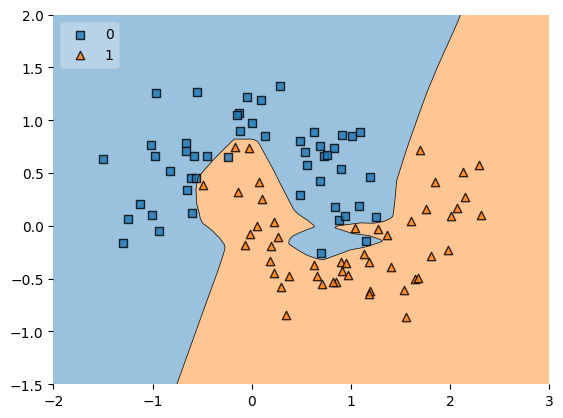

In [9]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

# through this, we can clearly say that there is overfitting happens.

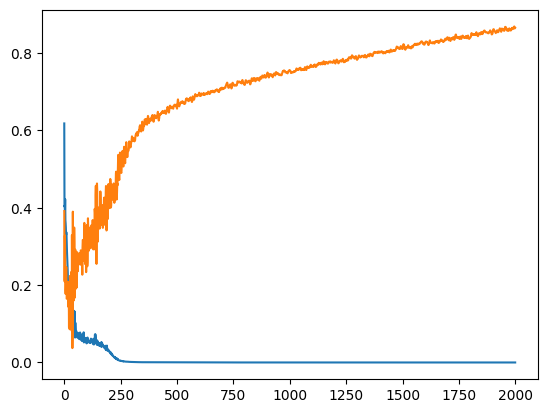

In [10]:
# let's also visualize it through the graph

plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [11]:
# this much gaps b/w both 'training_set' and 'validation_set' shows more chances of overfitting.

<h2> Using (L1 & L2)Regularization method </h2>

In [12]:
model2 = Sequential()

# here we use for 'l2-regularization' with (lambda_value=0.001)  
model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))  
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
adam = Adam(learning_rate=0.01)

In [14]:
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

In [18]:
history2 = model2.fit(X,y, epochs=2000, validation_split=0.2, verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


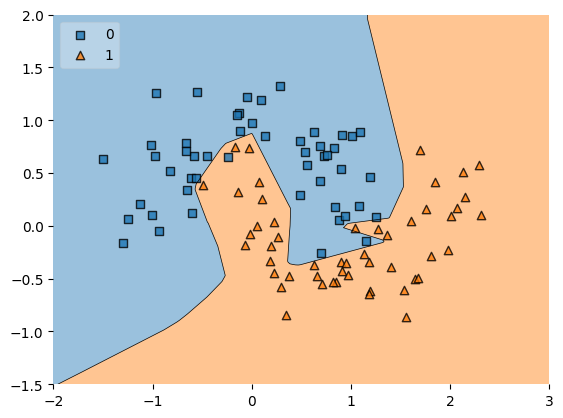

In [19]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

# now, this new 'decision_boundary' also performing on 'test_data' very well.

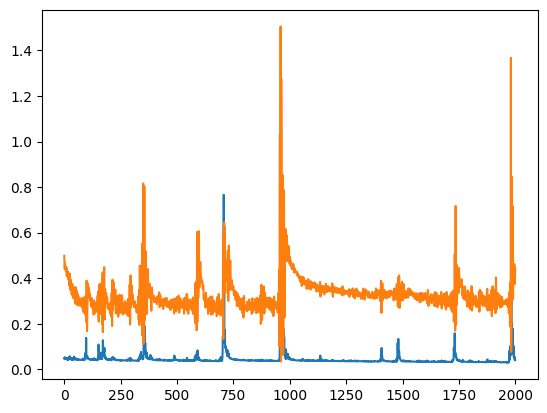

In [20]:
# let's also visulaize it through the graph

plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [23]:
# So finally, we solve the problem of overfitting using 'l2_regularization' at much extent

In [27]:
model1.get_weights()[0]

array([[ 1.88454270e-01,  1.55794928e-02, -4.76590008e-01,
         4.78086695e-02, -9.13243890e-02,  3.02349895e-01,
        -3.49696338e-01,  2.11760357e-01, -2.98166126e-02,
         2.00618386e-01, -8.25855583e-02, -4.11702901e-01,
        -3.03336024e-01,  2.34988987e-01, -5.31660497e-01,
        -4.99084860e-01,  2.39599809e-01,  2.38903642e-01,
        -2.23715469e-01,  1.60543829e-01, -3.71179700e-01,
        -2.36635789e-01,  9.54022557e-02, -5.03475487e-01,
        -6.89548627e-02, -4.71577942e-01,  1.22466289e-01,
         3.36126298e-01,  2.27579996e-01, -3.23019214e-02,
         1.76100597e-01,  1.51198525e-02, -4.14672107e-01,
         2.06270546e-01,  1.12738669e-01, -3.65556031e-01,
         8.35198327e-04, -5.21921277e-01, -3.58319968e-01,
        -6.02069438e-01,  2.97013521e-01, -1.85482144e-01,
         4.32422221e-01, -2.69359738e-01, -1.46485209e-01,
         3.07079136e-01, -2.47221887e-01, -4.40064490e-01,
         2.60410964e-01, -3.70507061e-01,  2.56195962e-0

In [31]:
# As it has 2 i/p and 128 nodes (in hidden layer) -> which total makes 256 nodes.

In [32]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

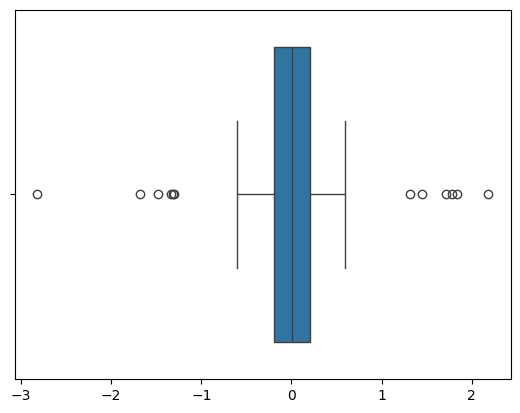

In [34]:
sns.boxplot(x=model1_weight_layer1)

<Axes: >

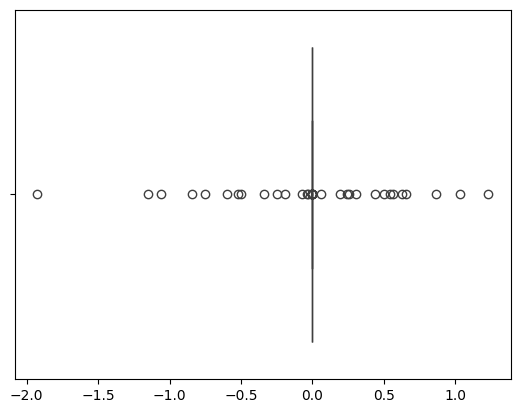

In [51]:
sns.boxplot(x=model2_weight_layer1)

# After applying boxplot, our values shrink b/w (-2) to 2.
# that shows 'weight_decay' and most of the weights are seen around '0'.

In [43]:
print("Min:", model1_weight_layer1.min())
print("Max:", model1_weight_layer1.max())

Min: -2.8175166
Max: 2.1824808


In [45]:
print("Min:", model2_weight_layer1.min())
print("Max:", model2_weight_layer1.max())

Min: -1.9248434
Max: 1.2319288


C:\Users\munna\AppData\Local\Temp\ipykernel_6764\2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
C:\Users\munna\AppData\Local\Temp\ipykernel_6764\2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

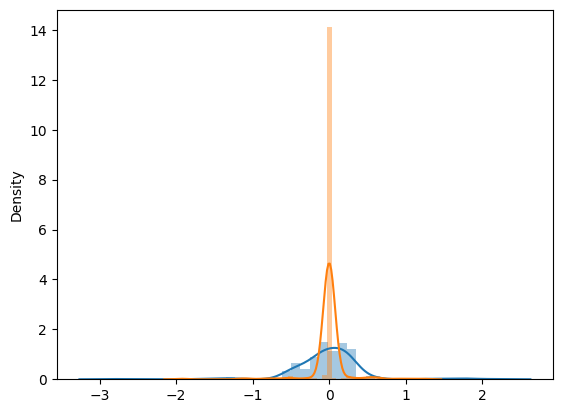

In [48]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [52]:
# here 'orange_curve' becomes normalized here and maximum of its weight lies around '0'.
# hence we can see that 'model2' follows 'normal-distribution-graph' as it solves the problem of overfitting.